In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# For saving and loading models
import joblib

# Display & plotting settings
pd.set_option('display.max_columns', None)
%matplotlib inline

In [19]:
df = pd.read_csv('student_exam_scores.csv')
df.head()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


In [20]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    object 
 1   hours_studied       200 non-null    float64
 2   sleep_hours         200 non-null    float64
 3   attendance_percent  200 non-null    float64
 4   previous_scores     200 non-null    int64  
 5   exam_score          200 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.5+ KB


,0
student_id,0
hours_studied,0
sleep_hours,0
attendance_percent,0
previous_scores,0
exam_score,0


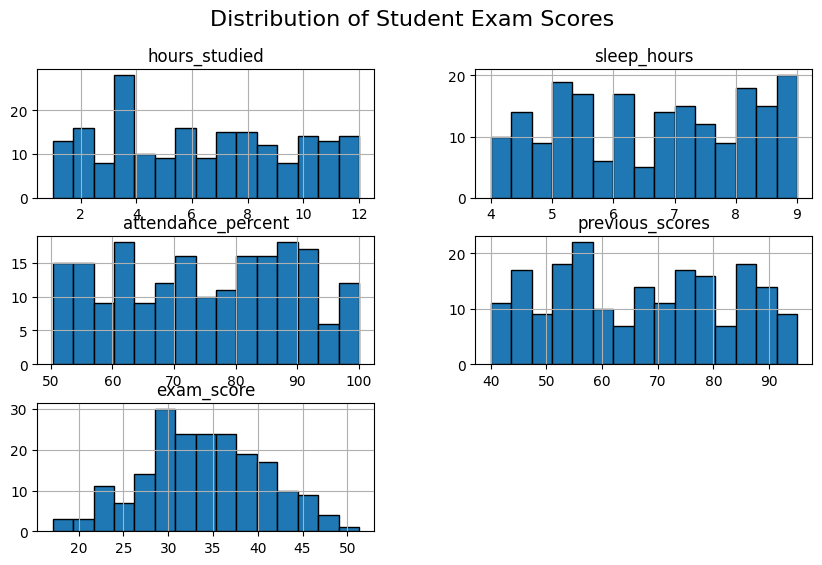

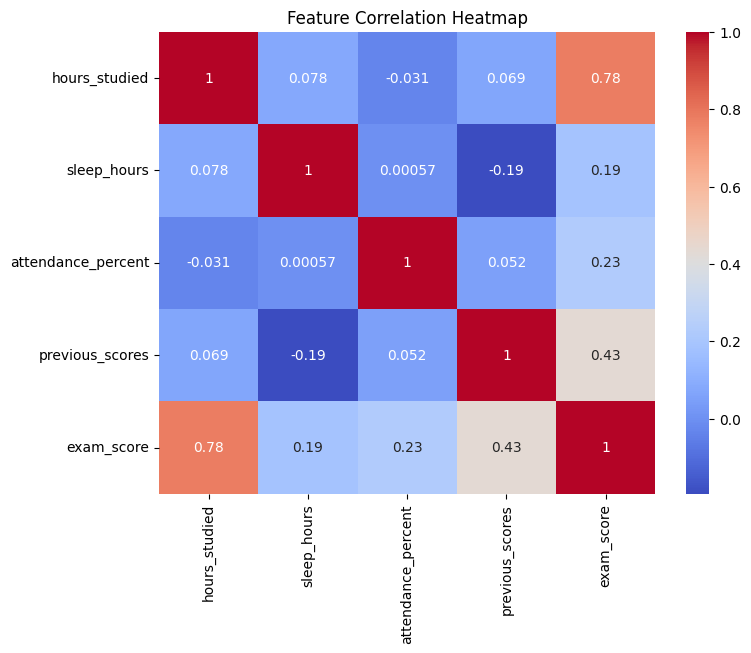

In [21]:
# Distributions
df.hist(figsize=(10, 6), bins=15, edgecolor='black')
plt.suptitle("Distribution of Student Exam Scores", fontsize=16)
plt.show()

# Correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [22]:
# Drop missing values
df = df.dropna()

# Convert categorical variables (if any)
df = pd.get_dummies(df, drop_first=True)

# Show processed columns
print("Processed Columns:", df.columns.tolist())

Processed Columns: ['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores', 'exam_score', 'student_id_S002', 'student_id_S003', 'student_id_S004', 'student_id_S005', 'student_id_S006', 'student_id_S007', 'student_id_S008', 'student_id_S009', 'student_id_S010', 'student_id_S011', 'student_id_S012', 'student_id_S013', 'student_id_S014', 'student_id_S015', 'student_id_S016', 'student_id_S017', 'student_id_S018', 'student_id_S019', 'student_id_S020', 'student_id_S021', 'student_id_S022', 'student_id_S023', 'student_id_S024', 'student_id_S025', 'student_id_S026', 'student_id_S027', 'student_id_S028', 'student_id_S029', 'student_id_S030', 'student_id_S031', 'student_id_S032', 'student_id_S033', 'student_id_S034', 'student_id_S035', 'student_id_S036', 'student_id_S037', 'student_id_S038', 'student_id_S039', 'student_id_S040', 'student_id_S041', 'student_id_S042', 'student_id_S043', 'student_id_S044', 'student_id_S045', 'student_id_S046', 'student_id_S047', 'student_id_S048', 

In [23]:
# Change 'Exam_Score' if your dataset uses a different name
target_col = 'exam_score'

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# Linear Regression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
lin_pred = lin_model.predict(X_test)

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)


In [25]:
# Evaluate both models
def evaluate_model(name, y_true, y_pred):
    print(f"{name} Results:")
    print("  MSE:", mean_squared_error(y_true, y_pred))
    print("  R²:", r2_score(y_true, y_pred))
    print("-" * 40)

evaluate_model("Linear Regression", y_test, lin_pred)
evaluate_model("Random Forest", y_test, rf_pred)

Linear Regression Results:
  MSE: 14.89971577158433
  R²: 0.7192446260401935
----------------------------------------
Random Forest Results:
  MSE: 11.195725850000008
  R²: 0.7890389155098632
----------------------------------------


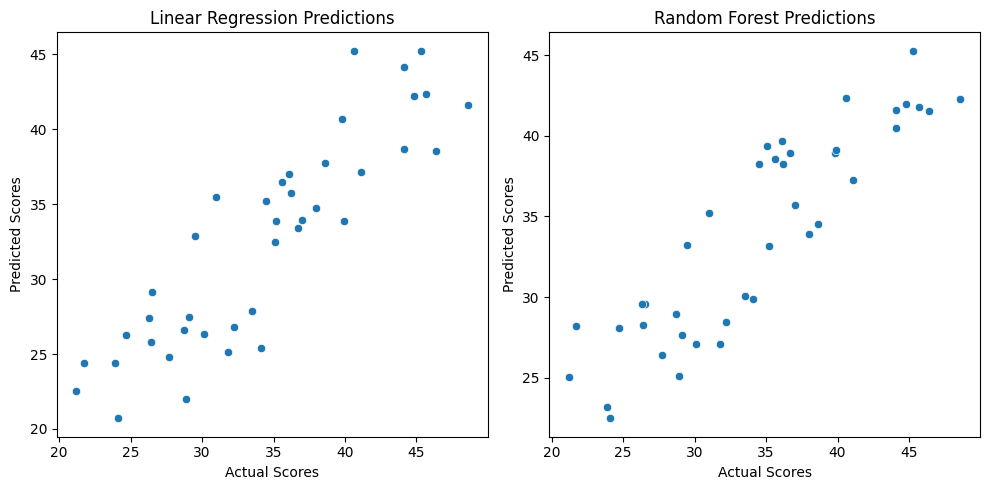

In [26]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=lin_pred)
plt.title("Linear Regression Predictions")
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=rf_pred)
plt.title("Random Forest Predictions")
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")

plt.tight_layout()
plt.show()

In [27]:
# Save model
joblib.dump(rf_model, 'student_exam_rf_model.pkl')
print("✅ Random Forest model saved as 'student_exam_rf_model.pkl'")

# (Optional) Save column names for later use
joblib.dump(X.columns.tolist(), 'model_features.pkl')
print("✅ Feature list saved as 'model_features.pkl'")

✅ Random Forest model saved as 'student_exam_rf_model.pkl'
✅ Feature list saved as 'model_features.pkl'
